# Lane Detection using OpenCV


## Part 1 : Modifying the code and test in a gei

In [130]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Function modified to YCrCb
def dark_tape_mask(
    bgr_image,
    lower_ycrcb=np.array([0,   100,  100]),  # Param to Adapt
    upper_ycrcb=np.array([110, 140, 140]),    # Param to Adapt
    kernel_size=5
):
    # BGR -> YCrCb
    ycrcb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2YCrCb)

    # Threshold for dark, low‑chroma pixels (black-ish)
    mask = cv2.inRange(ycrcb, lower_ycrcb, upper_ycrcb)

    # Morphological filtering to keep thick blobs and remove noise
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    return mask

def centerline_from_mask(mask, kernel_size=3):

    # erode to shrink the thick lane
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded = cv2.erode(mask, kernel, iterations=1)
    
    # Skeletonize using morphological thinning
    size = np.size(eroded)
    skel = np.zeros(eroded.shape, np.uint8)

    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    done = False
    
    while not done:
        eroded_temp = cv2.erode(eroded, element)
        temp = cv2.dilate(eroded_temp, element)
        temp = cv2.subtract(eroded, temp)
        skel = cv2.bitwise_or(skel, temp)
        eroded = eroded_temp.copy()
        if cv2.countNonZero(eroded) == 0:
            done = True
    return skel

def prune_small_components(skel, min_size=150):
    # skel: binary 0/255, uint8
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(skel, connectivity=8)

    pruned = np.zeros_like(skel)
    for i in range(1, num_labels):      # 0 is background
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_size:
            pruned[labels == i] = 255
    return pruned


def polynomial_lane_fit(edges, min_points=500):
    ys, xs = np.where(edges > 0)

    if len(xs) < min_points:
        return None, None

    coeffs = np.polyfit(ys, xs, 1)
    return coeffs, ys

# Remove irrelevant segments of the image and retain only the lane portion
def roi_on_mask(mask, roi_top_ratio=0.55, roi_bottom_ratio=0.05):
    # mask: single-channel (uint8) 0/255
    h, w = mask.shape[:2]
    roi_mask = np.zeros_like(mask)
    roi_top = int(h * roi_top_ratio)
    roi_bottom = int(h * (1 - roi_bottom_ratio))
    cv2.rectangle(roi_mask, (0, roi_top), (w, roi_bottom), 255, -1)
    return cv2.bitwise_and(mask, roi_mask)

def split_left_right_edges(edges):
    ys, xs = np.where(edges > 0)
    if len(xs) == 0:
        return (None, None), (None, None)

    h, w = edges.shape[:2]
    x_mid = w / 2.0

    left  = xs < x_mid
    right = xs >= x_mid

    return (ys[left], xs[left]), (ys[right], xs[right])

def polynomial_fit_from_points(ys, xs, min_points=50, min_span=40):
    if xs is None or len(xs) < min_points:
        return None
    if ys.max() - ys.min() < min_span:
        return None
    return np.polyfit(ys, xs, 1)




def detect_lanes_dark_tape_no_canny(input_image):
    # color mask and get the skeleton of the lanes
    mask = dark_tape_mask(input_image)
    mask_skel = centerline_from_mask(mask)
    mask_skel = prune_small_components(mask_skel, min_size=80)

    # apply ROI directly on skeleton
    roi_skel = roi_on_mask(mask_skel)

    # split points and fit lines
    (left_y, left_x), (right_y, right_x) = split_left_right_edges(roi_skel)

    left_coeffs  = polynomial_fit_from_points(left_y,  left_x,  min_points=50)
    right_coeffs = polynomial_fit_from_points(right_y, right_x, min_points=50)

    return left_coeffs, right_coeffs, roi_skel, mask

def draw_lines(image, left_coeffs=None, right_coeffs=None, thickness=8, color=(0, 0, 255), y_min_ratio=0.55):

    line_image = np.zeros_like(image)
    h = image.shape[0]
    y_min = int(h * y_min_ratio)
    y_max = h

    for coeffs in [left_coeffs, right_coeffs]:
        if coeffs is not None:
            b, c = coeffs
            x1 = int(b*y_min + c)
            x2 = int(b*y_max + c)
            cv2.line(line_image, (x1, y_min), (x2, y_max), color, thickness)

    return cv2.addWeighted(image, 0.8, line_image, 1.0, 0.0)





#### Section with the set of images for testing parameter

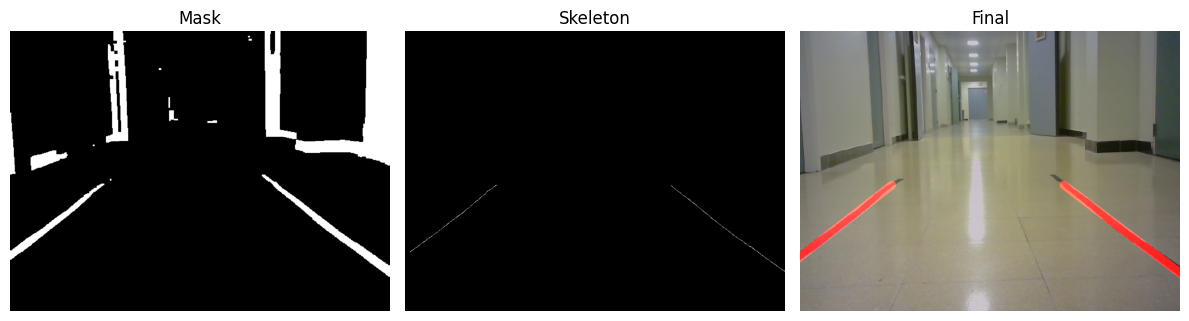

In [131]:
# Image Test 1
inputimage = cv2.imread("test_demo.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()




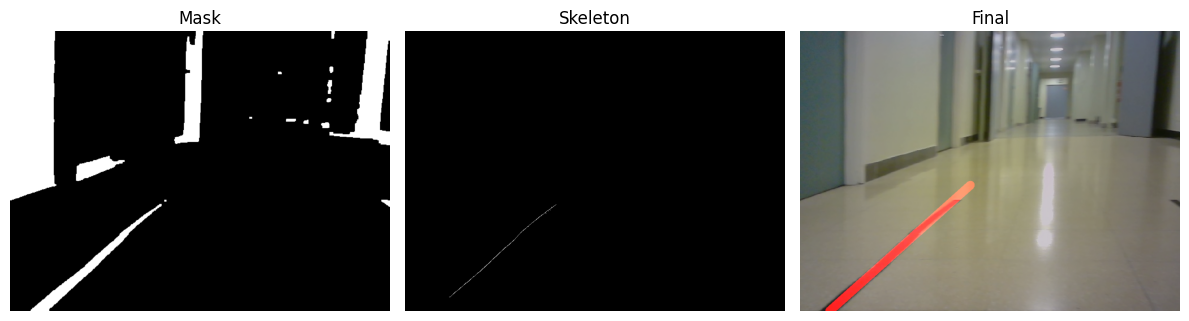

In [132]:
# Image Test 2
inputimage = cv2.imread("test_demo2.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()


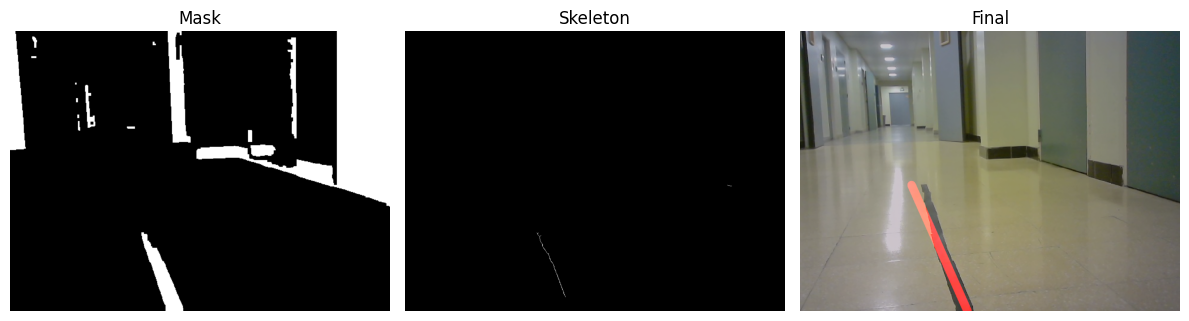

In [133]:
# Image Test 3
inputimage = cv2.imread("test_demo3.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()




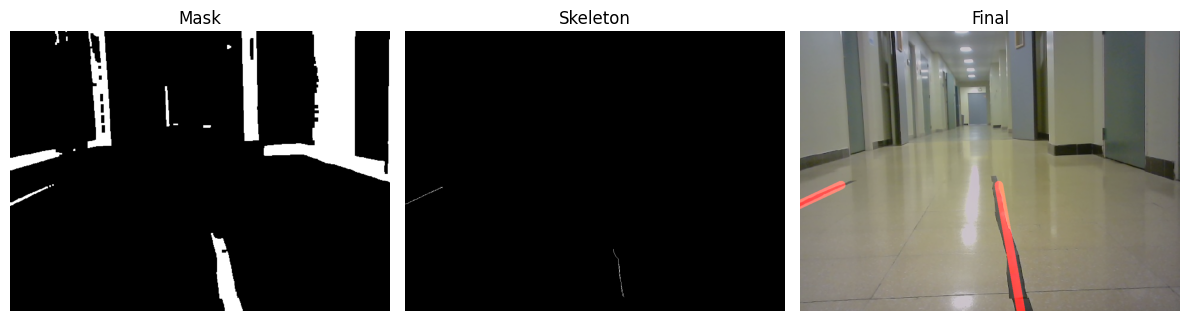

In [134]:
# Image Test 4
inputimage = cv2.imread("test_demo4.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()



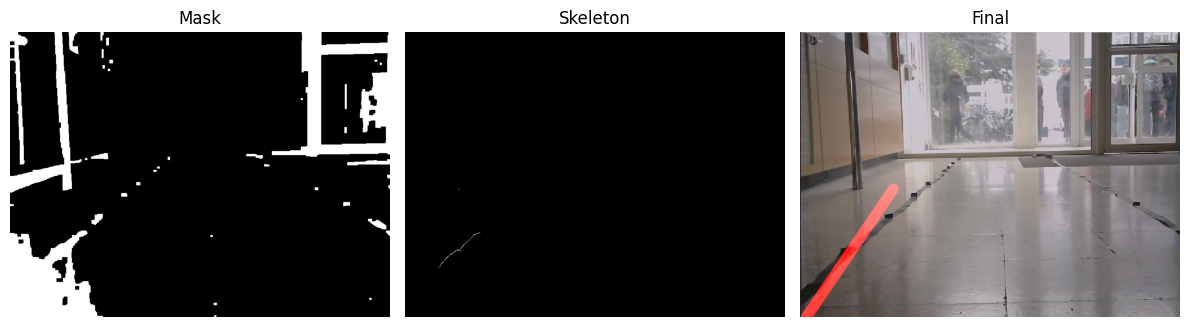

In [135]:
# Image Test 5
inputimage = cv2.imread("test5.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()



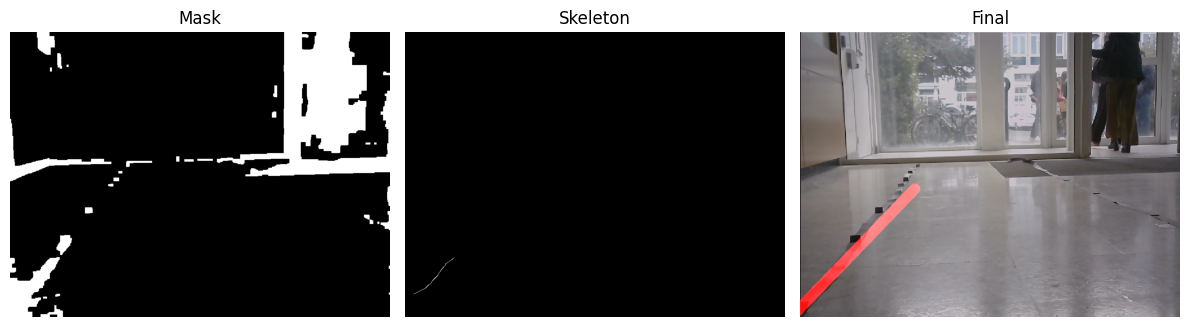

In [136]:
# Image Test 6
inputimage = cv2.imread("test6.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()



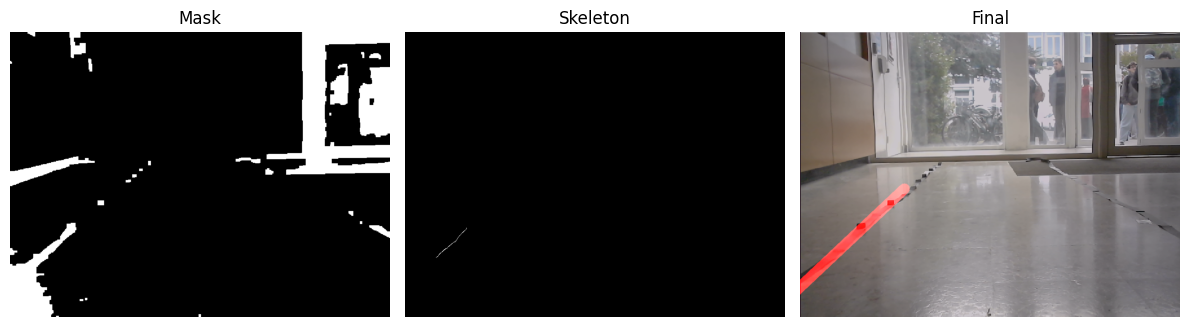

In [137]:
# Image Test 7
inputimage = cv2.imread("test7.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()